### **DC Account Analysis for the Recovery Teams**
# Importing Librariesand Loading  the data


In [80]:
import pandas as pd
import numpy as np
agreements = pd.read_excel('Sample_data.xlsx', sheet_name='agreements')
payments = pd.read_excel('Sample_data.xlsx', sheet_name='payments')
gps = pd.read_excel('Sample_data.xlsx', sheet_name='gps_status')
branches = pd.read_excel('Sample_data.xlsx', sheet_name='branches')
print('Data Loaded')

#2. CLEAN & PREPARE
agreements['loan_product'] = agreements['loan_product'].str.lower().str.strip()
agreements = agreements.merge(branches, left_on='branch', right_on='branch_name', how='left')
print("Data cleaned")

Data Loaded
Data cleaned


Feature engineering

In [81]:
# Payments summary
payments_agg = payments.groupby('loan_id')['amount_paid'].sum().reset_index(name='total_paid')

# Merge everything
df = agreements.merge(payments_agg, on='loan_id', how='left').fillna({'total_paid': 0})
df = df.merge(gps, on='loan_id', how='left')

# Key calculations
df['collection_rate'] = np.where(df['outstanding_balance'] > 0,
                                df['total_paid'] / df['outstanding_balance'], 0)

def dpd_bucket(dpd):
    if dpd == 0: return "0"
    elif dpd <= 30: return "1-30"
    elif dpd <= 60: return "31-60"
    elif dpd <= 90: return "61-90"
    else: return "91+"

df['dpd_bucket'] = df['max_dpd'].apply(dpd_bucket)

print("Data prepared successfully!\n")
df.head(5)


Data prepared successfully!



,loan_id,branch,loan_product,loan_status,loan_amount,currency,monthly_installment,term_months,disbursement_date,max_dpd,outstanding_balance,branch_name,region,total_paid,gps_status,gps_last_seen_date,collection_rate,dpd_bucket
0,1,Kilifi - Branch - Pwani (Bodas),logbook_loan,active,39804.00,KSH,2173,25,2024-12-17,29,12060,Kilifi - Branch - Pwani (Bodas),Coast,48240.0,0.0,2025-04-12,4.000000,1-30
1,2,Thika - Branch - Ananas Mall (Cars),logbook_loan,active,215140.00,KSH,20417,21,2024-12-17,33,48177,Thika - Branch - Ananas Mall (Cars),Nairobi,100545.0,1.0,2026-06-17,2.086992,31-60
2,3,Kikuyu - Branch - Ivory Tower (Hybrid),financing,active,256154.32,KSH,26146,17,2024-12-17,30,26146,Kikuyu - Branch - Ivory Tower (Hybrid),Nairobi,167434.0,1.0,2026-06-17,6.403809,1-30
3,4,Kisii - Branch - B3 Rd (Hybrid),financing,active,108212.71,KSH,3495,50,2024-12-17,9,8485,Kisii - Branch - B3 Rd (Hybrid),Nyanza,93160.0,1.0,2026-01-16,10.979375,1-30
4,5,Kisii - Branch - B3 Rd (Hybrid),logbook_loan,active,40117.86,KSH,1746,35,2024-12-17,27,9319,Kisii - Branch - B3 Rd (Hybrid),Nyanza,36505.0,0.0,2026-04-07,3.917266,1-30


# **REPORTS**

1.PORTFOLIO OVERVIEW

In [82]:
# 1. Portfolio Overview
portfolio = df.groupby('dpd_bucket').agg(
    Outstanding=('outstanding_balance', 'sum'),
    Loans=('loan_id', 'count')
).round(0)
print("Portfolio Overview\n", portfolio, "\n")


Portfolio Overview
             Outstanding  Loans
dpd_bucket                    
0               5599878    630
1-30           38284614   2267
31-60          45030417    855
61-90          10872774    113
91+             9939977    135 



2.BRANCH PERFORMANCE

In [83]:
# 2. Branch Performance
branch_perf = df.groupby(['branch', 'region']).agg(
    Outstanding=('outstanding_balance', 'sum'),
    Total_Paid=('total_paid', 'sum'),
    Avg_Collection=('collection_rate', 'mean'),
    Loans=('loan_id', 'count')
).round(3)
branch_perf = branch_perf.sort_values('Avg_Collection', ascending=False)
print("Branch Performance (Top 10) \n", branch_perf.head(10), "\n")


Branch Performance (Top 10) 
                                                 Outstanding  Total_Paid  \
branch                                 region                             
Car Yard                               Other        1676735    736653.0   
Kilifi - Branch - Pwani (Bodas / Cars) Coast         258992    513763.0   
Mombasa - Branch - Jubilee (Cars)      Coast         344899    597999.0   
Kisumu - Branch - CBD (Bodas / Cars)   Nyanza         98635     86808.0   
Kisumu - Branch - CBD (Cars)           Nyanza        315055    212845.0   
Bondo - Branch - Rubis (Hybrid)        Nyanza        385551     62204.0   
Dealerships                            Other       11797637   2701468.0   
Nakuru - Branch - Riria Hub (Cars)     Nakuru       2671641    966734.0   
Nairobi - Branch - Ruiru (Hybrid)      Nairobi      5408604    699400.0   
Kikuyu - Branch - Ivory Tower (Hybrid) Nairobi       944964    269329.0   

                                                Avg_Collection  Loans

3.PRODUCT ANALYSIS

In [84]:
# 3. Product Analysis
product = df.groupby('loan_product').agg(
    Avg_DPD=('max_dpd', 'mean'),
    Avg_Outstanding=('outstanding_balance', 'mean'),
    Collection_Rate=('collection_rate', 'mean')
).round(2)
print("Product Analysis \n", product, "\n")


Product Analysis 
               Avg_DPD  Avg_Outstanding  Collection_Rate
loan_product                                           
financing       23.74         28521.37             0.87
logbook loan    29.60         30899.70             0.71
logbook_loan    34.40         25389.41             0.68 




4. GPS $ REPOSSESSION - HIGH RISK




Automating the report


In [85]:
# 4. GPS & Repossession (High Risk)
high_risk = df[df['max_dpd'] >= 30].copy()
high_risk = high_risk.sort_values('max_dpd', ascending=False).head(20)
print("Top 20 High Risk Loans (GPS & Repossession) \n",
      high_risk[['loan_id', 'branch', 'max_dpd', 'outstanding_balance', 'gps_status']])


Top 20 High Risk Loans (GPS & Repossession) 
       loan_id                                   branch  max_dpd  \
261       262  Kisumu - Branch - Fire Station (Hybrid)      403   
2997     2998      Mombasa - Branch - Express (Hybrid)      389   
752       753      Mombasa - Branch - Express (Hybrid)      362   
3475     3476            Bomet - Branch - CBD (Hybrid)      334   
1046     1047   Machakos - Branch - Beam Towers (Cars)      332   
2317     2318          Bondo - Branch - Rubis (Hybrid)      313   
3019     3020                              Dealerships      307   
2274     2275      Mombasa - Branch - Express (Hybrid)      305   
2775     2776          Kisii - Branch - B3 Rd (Hybrid)      299   
796       797          Kisii - Branch - B3 Rd (Hybrid)      294   
2549     2550       Nairobi - Branch - Subaru (Hybrid)      291   
2082     2083       Nairobi - Branch - Subaru (Hybrid)      289   
2201     2202      Mombasa - Branch - Express (Hybrid)      275   
2116     2117  K

In [86]:
with pd.ExcelWriter('Automated_Loan_Report.xlsx', engine='openpyxl') as writer:
    portfolio.to_excel(writer, sheet_name='Portfolio Overview')
    branch_perf.to_excel(writer, sheet_name='Branch Performance')
    product.to_excel(writer, sheet_name='Product Analysis')
    high_risk.to_excel(writer, sheet_name='GPS Repossession', index=False)

print("\n Reports saved to 'Final_Report.xlsx'")


 Reports saved to 'Final_Report.xlsx'


In [96]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from google.colab import files


In [ ]:
z

Outstanding Balance by DPD Buckets

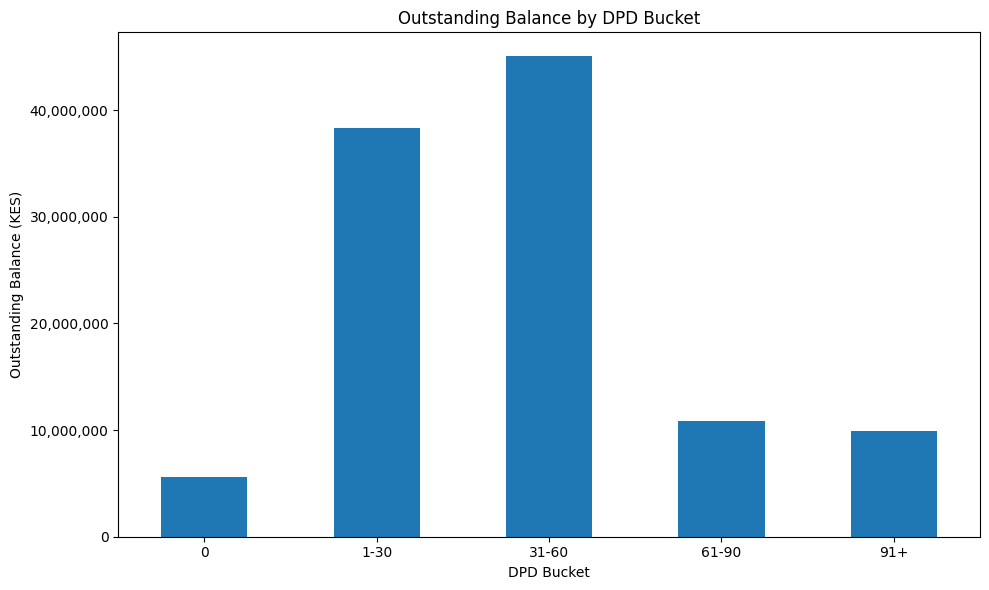

In [97]:
plt.figure(figsize=(10,6))

portfolio['Outstanding'].plot(kind='bar')

plt.title('Outstanding Balance by DPD Bucket')
plt.xlabel('DPD Bucket')
plt.ylabel('Outstanding Balance (KES)')

plt.gca().yaxis.set_major_formatter(
    mtick.StrMethodFormatter('{x:,.0f}')
)

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig('Portfolio_Overview.png', dpi=300)

plt.show()

Outstanding Balances By Branches

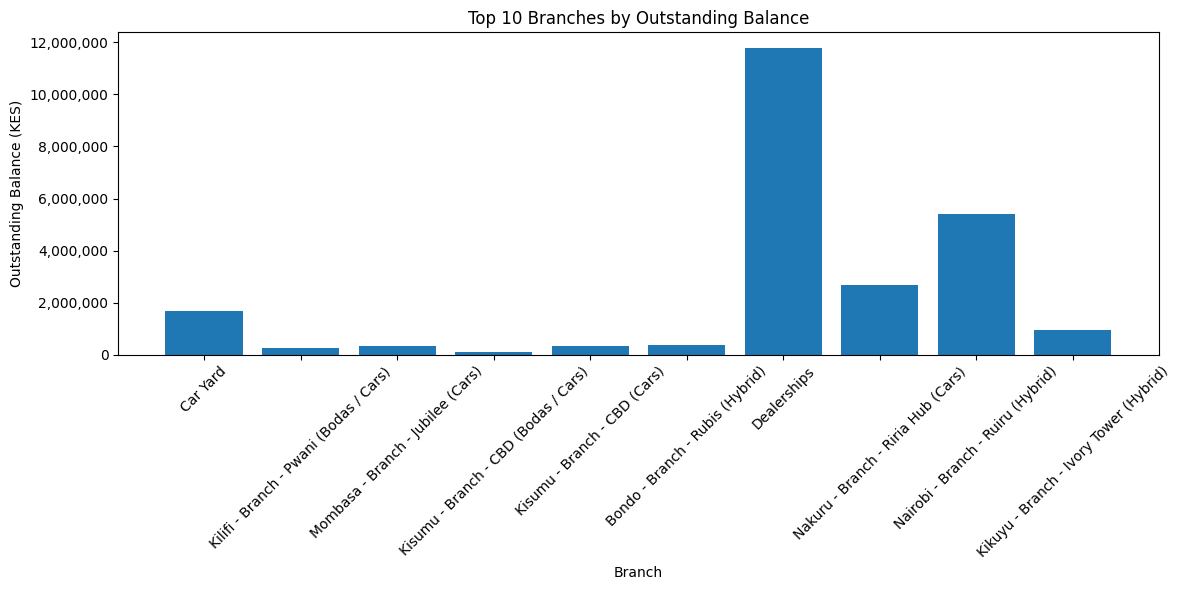

In [98]:
top_branches = branch_perf.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top_branches.index.get_level_values('branch'),
    top_branches['Outstanding']
)

plt.title('Top 10 Branches by Outstanding Balance')
plt.xlabel('Branch')
plt.ylabel('Outstanding Balance (KES)')

plt.gca().yaxis.set_major_formatter(
    mtick.StrMethodFormatter('{x:,.0f}')
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig('Branch_Outstanding.png', dpi=300)

plt.show()

Average Collection rate by branch

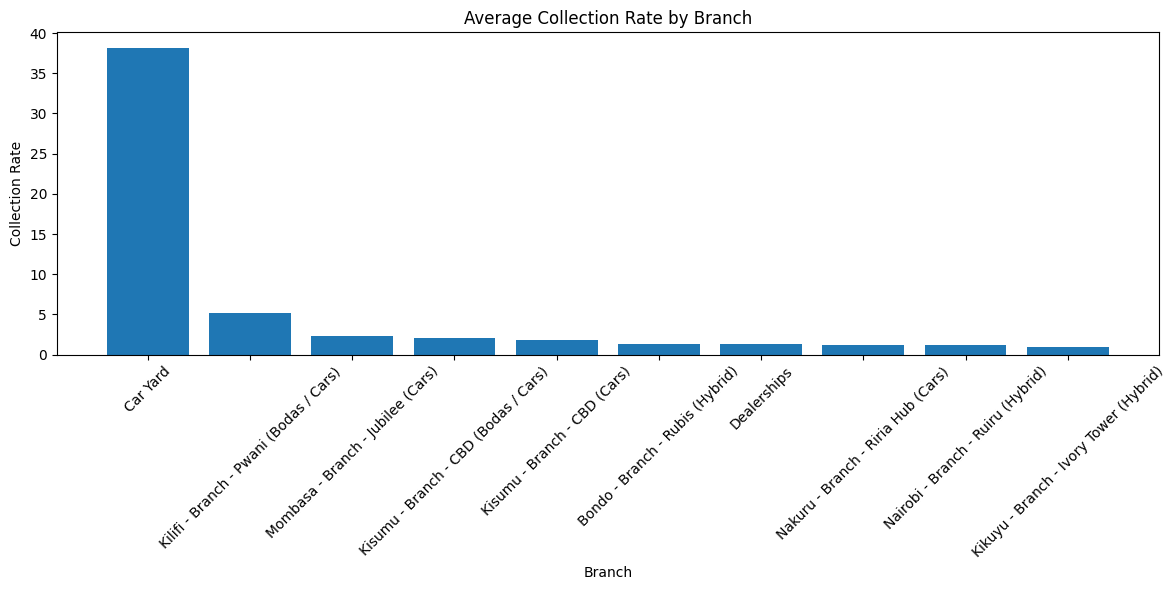

In [99]:
plt.figure(figsize=(12,6))

plt.bar(
    top_branches.index.get_level_values('branch'),
    top_branches['Avg_Collection']
)

plt.title('Average Collection Rate by Branch')
plt.xlabel('Branch')
plt.ylabel('Collection Rate')

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig('Branch_Collection_Rate.png', dpi=300)

plt.show()



Average collection rate by loan product


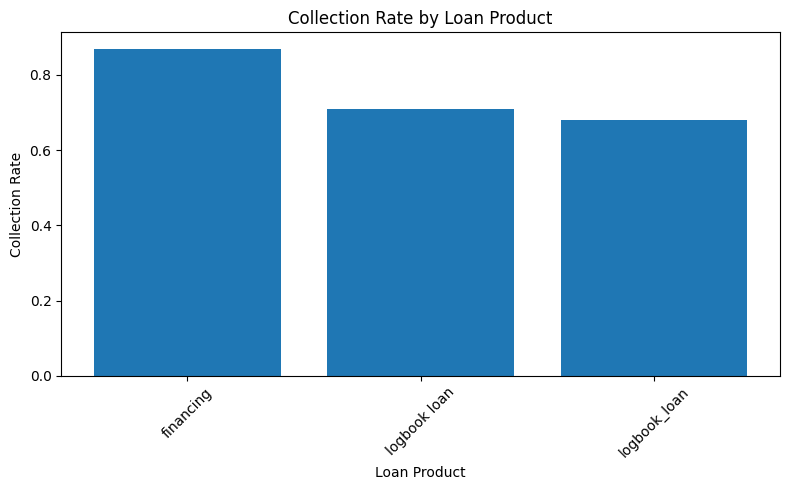

In [100]:
plt.figure(figsize=(8,5))

plt.bar(
    product.index,
    product['Collection_Rate']
)

plt.title('Collection Rate by Loan Product')
plt.xlabel('Loan Product')
plt.ylabel('Collection Rate')

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig('Product_Collection_Rate.png', dpi=300)

plt.show()
plt.show()



* Outstanding balance by Loan product


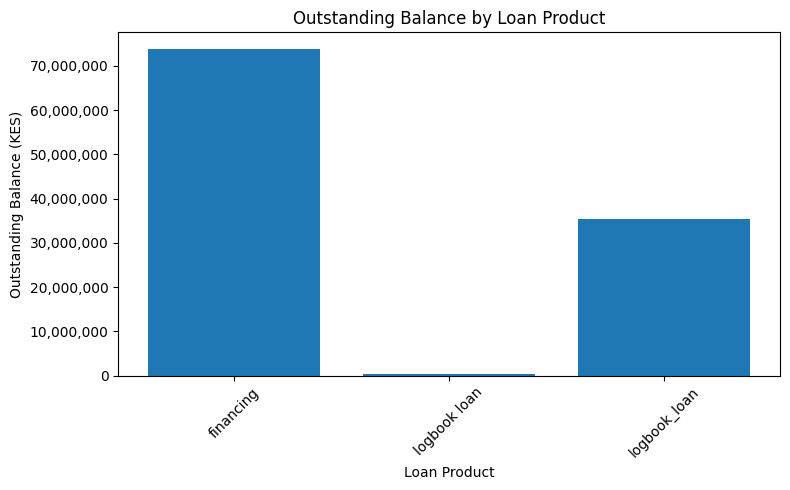

In [101]:
product_balance = df.groupby(
    'loan_product'
)['outstanding_balance'].sum()

plt.figure(figsize=(8,5))

plt.bar(
    product_balance.index,
    product_balance.values
)

plt.title('Outstanding Balance by Loan Product')
plt.xlabel('Loan Product')
plt.ylabel('Outstanding Balance (KES)')

plt.gca().yaxis.set_major_formatter(
    mtick.StrMethodFormatter('{x:,.0f}')
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig('Outstanding_by_Product.png', dpi=300)

plt.show()

GPS status for all accounts

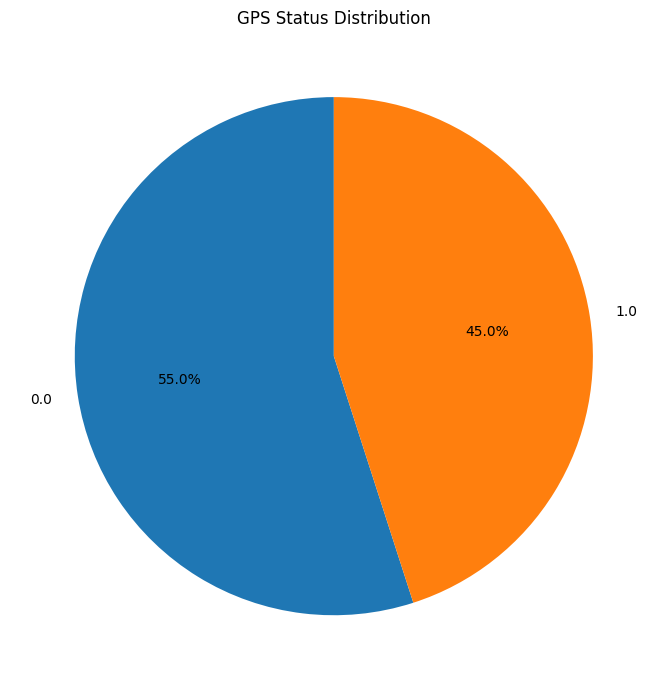

In [102]:
gps_summary = df['gps_status'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    gps_summary,
    labels=gps_summary.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('GPS Status Distribution')

plt.tight_layout()

plt.savefig('GPS_Status_Distribution.png', dpi=300)

plt.show()


Loan distribution by buckets

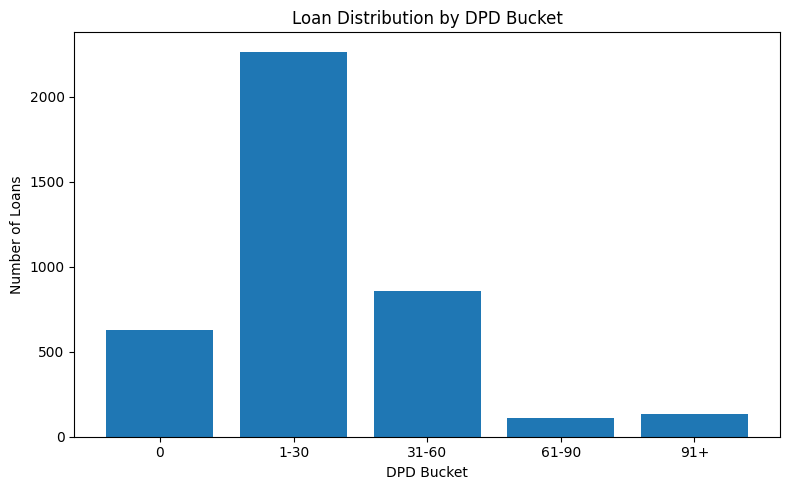

In [103]:
dpd_summary = df['dpd_bucket'].value_counts().sort_index()

plt.figure(figsize=(8,5))

plt.bar(
    dpd_summary.index,
    dpd_summary.values
)

plt.title('Loan Distribution by DPD Bucket')
plt.xlabel('DPD Bucket')
plt.ylabel('Number of Loans')

plt.tight_layout()

plt.savefig('DPD_Distribution.png', dpi=300)

plt.show()

Top 20 Risky Loans that Need to be forwaded to the field collection team.

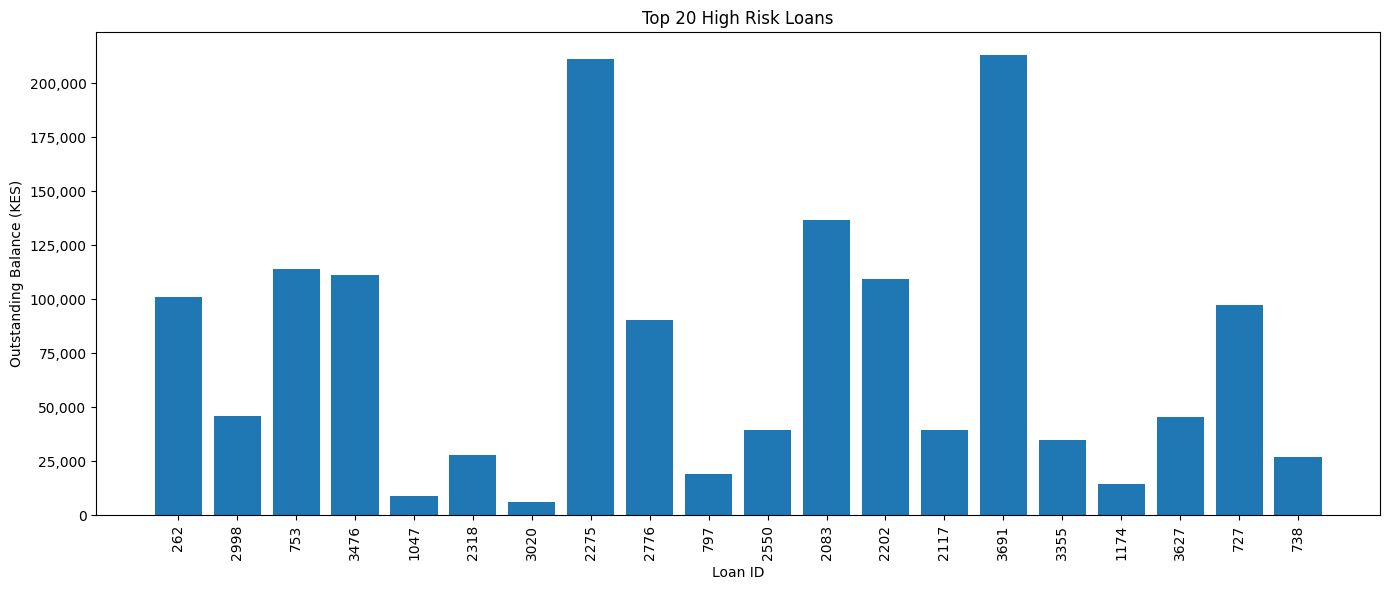

In [104]:
plt.figure(figsize=(14,6))

plt.bar(
    high_risk['loan_id'].astype(str),
    high_risk['outstanding_balance']
)

plt.title('Top 20 High Risk Loans')
plt.xlabel('Loan ID')
plt.ylabel('Outstanding Balance (KES)')

plt.gca().yaxis.set_major_formatter(
    mtick.StrMethodFormatter('{x:,.0f}')
)

plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig('High_Risk_Loans.png', dpi=300)

plt.show()

In [105]:
files.download('Portfolio_Overview.png')
files.download('Branch_Outstanding.png')
files.download('Branch_Collection_Rate.png')
files.download('Product_Collection_Rate.png')
files.download('Outstanding_by_Product.png')
files.download('GPS_Status_Distribution.png')
files.download('DPD_Distribution.png')
files.download('High_Risk_Loans.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>